In [147]:
pip install pandas as pd

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for as


In [148]:
import os
print("Mi directorio actual es:", os.getcwd())
print("¿Están los archivos aquí?:", os.listdir('.'))

Mi directorio actual es: c:\www\Curso_the_power\Python\proyecto_final\notebooks
¿Están los archivos aquí?: ['01_EDA_y_Limpieza.ipynb', 'CLV_Fuente1_Transacciones.csv', 'CLV_Fuente2_Perfiles_Clientes.csv', 'dataset_final_limpio.csv']


In [149]:
import pandas as pd

#Definimos los nombres de archivo
archivo1 = 'CLV_Fuente1_Transacciones.csv'
archivo2 = 'CLV_Fuente2_Perfiles_Clientes.csv'

#Leemos forzando el separador ';' y la codificación 'latin1'
#Si el separador no es ';', Pandas nos avisará, pero esto suele arreglar el 99% de los casos.
df_transacciones = pd.read_csv(archivo1, sep=';', encoding='latin1')
df_perfiles = pd.read_csv(archivo2, sep=';', encoding='latin1')

#Unimos
df_final = pd.merge(df_transacciones, df_perfiles, on='ID_Cliente', how='left')

#Verificación
print("✅ ¡Archivos cargados correctamente!")
print(f"Dimensiones finales: {df_final.shape}")
df_final.info()

✅ ¡Archivos cargados correctamente!
Dimensiones finales: (604568, 43)
<class 'pandas.DataFrame'>
RangeIndex: 604568 entries, 0 to 604567
Data columns (total 43 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   ID_Transaccion       604568 non-null  str  
 1   ID_Cliente           604568 non-null  str  
 2   ID_Producto          604568 non-null  str  
 3   Categoría_Producto   604568 non-null  str  
 4   Subcategoría         604568 non-null  str  
 5   Fecha_Transaccion    604568 non-null  str  
 6   Año                  604568 non-null  int64
 7   Mes                  604568 non-null  int64
 8   Trimestre            604568 non-null  str  
 9   Cantidad             604568 non-null  int64
 10  Precio_Unitario      604568 non-null  str  
 11  Descuento_Pct        604568 non-null  str  
 12  Precio_Final_Unit    604568 non-null  str  
 13  Importe_Total        604568 non-null  str  
 14  Coste_Produccion     604568 non-null  str

In [150]:
#Convertimos columnas monetarias a float (por si el CSV las leyó como texto por algún símbolo)
cols_monetarias = ['Precio_Final_Unit', 'Importe_Total', 'Margen_Bruto', 'Ingreso_Estimado']
for col in cols_monetarias:
    #Eliminamos cualquier símbolo de moneda si existiera y convertimos a numérico
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

#Convertimos las fechas a formato datetime (¡Vital para el EDA temporal!)
df_final['Fecha_Transaccion'] = pd.to_datetime(df_final['Fecha_Transaccion'], errors='coerce')
df_final['Fecha_Alta'] = pd.to_datetime(df_final['Fecha_Alta'], errors='coerce')

#Verificamos si quedaron nulos después de la conversión
print("Nulos tras la limpieza:")
print(df_final[cols_monetarias].isnull().sum())

Nulos tras la limpieza:
Precio_Final_Unit    598167
Importe_Total        598656
Margen_Bruto         598668
Ingreso_Estimado     598808
dtype: int64


In [151]:
#Seleccionamos solo las columnas numéricas (int y float)
df_numerico = df_final.select_dtypes(include=['int64', 'float64'])

#Ahora sí calculamos la matriz de correlación
matriz_corr = df_numerico.corr()

#Para visualizar mejor la correlación con 'Importe_Total', extraemos esa fila
correlacion_importe = matriz_corr['Importe_Total'].sort_values(ascending=False)

print("--- Correlación de variables con el Importe Total ---")
print(correlacion_importe)

--- Correlación de variables con el Importe Total ---
Importe_Total        1.000000
Puntos_Generados     0.999741
Precio_Final_Unit    0.760960
Ingreso_Estimado     0.739400
Cantidad             0.428533
Num_Reclamaciones    0.051197
Mes                  0.037437
Puntos_Acumulados    0.009133
NPS_Score            0.003715
Edad                -0.012600
Año                 -0.024880
Churn_Flag          -0.039471
Margen_Bruto              NaN
Name: Importe_Total, dtype: float64


In [152]:
#Filtramos solo columnas numéricas (enteros y flotantes)
df_numerico = df_final.select_dtypes(include=['int64', 'float64'])

#Calculamos la matriz de correlación solo sobre estos datos
matriz_corr = df_numerico.corr()

#Mostramos las correlaciones de todas las variables frente a 'Importe_Total'. Esto dirá qué factores realmente hacen que un cliente gaste más
correlacion_importe = matriz_corr['Importe_Total'].sort_values(ascending=False)

print("--- Variables más relacionadas con el Importe Total ---")
print(correlacion_importe.head(10))

--- Variables más relacionadas con el Importe Total ---
Importe_Total        1.000000
Puntos_Generados     0.999741
Precio_Final_Unit    0.760960
Ingreso_Estimado     0.739400
Cantidad             0.428533
Num_Reclamaciones    0.051197
Mes                  0.037437
Puntos_Acumulados    0.009133
NPS_Score            0.003715
Edad                -0.012600
Name: Importe_Total, dtype: float64


In [153]:
print(f"¿Hay filas duplicadas?: {df_final.duplicated().sum()}")
#Si sale > 0, elimínarlas:
df_final = df_final.drop_duplicates()

¿Hay filas duplicadas?: 0


In [154]:
#Verificamos si hay edades fuera de lógica
print("Clientes con edad sospechosa:", df_final[(df_final['Edad'] < 18) | (df_final['Edad'] > 100)].shape[0])

#Verificamos si hay importes negativos
print("Transacciones con importe negativo:", df_final[df_final['Importe_Total'] < 0].shape[0])

Clientes con edad sospechosa: 0
Transacciones con importe negativo: 0


In [155]:
#Contamos cuántos ceros hay en columnas donde no debería haberlos
print("Ceros en 'Precio_Final_Unit':", (df_final['Precio_Final_Unit'] == 0).sum())

Ceros en 'Precio_Final_Unit': 0


In [156]:
#Esto elimina automáticamente cualquier columna que esté completamente vacía
df_final = df_final.dropna(axis=1, how='all')

In [157]:
#Campos Monetarios: Rellenar con 0
cols_monetarias = ['Precio_Final_Unit', 'Importe_Total', 'Margen_Bruto', 'Ingreso_Estimado']
df_final[cols_monetarias] = df_final[cols_monetarias].fillna(0)

#Campos de Categoría: Rellenar con 'Desconocido'
cols_cat = ['Nombre_Segmento', 'Dispositivo'] # Añade aquí las que veas necesarias
df_final[cols_cat] = df_final[cols_cat].fillna('Desconocido')

#Campos Críticos (Fechas/IDs): Eliminar filas donde falte información esencial
df_final = df_final.dropna(subset=['Fecha_Transaccion', 'ID_Cliente'])

print("✅ Limpieza estratégica completada.")

✅ Limpieza estratégica completada.


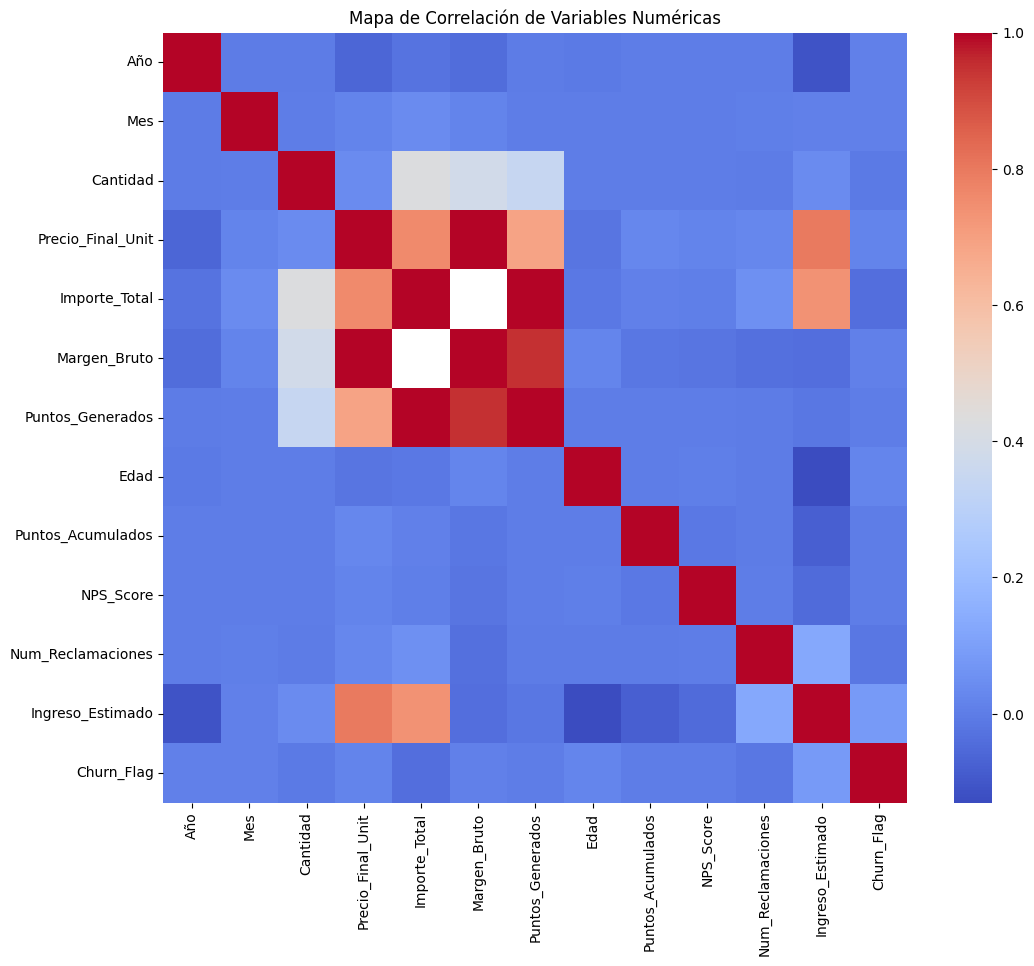

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt

#Configuramos el tamaño del gráfico para que no se vea pequeño
plt.figure(figsize=(12, 10))

#Creamos el mapa de calor (Heatmap)
#annot=True pone los números dentro de los cuadraditos
sns.heatmap(matriz_corr, annot=False, cmap='coolwarm', fmt=".2f")

#Le ponemos título
plt.title('Mapa de Correlación de Variables Numéricas')

#¡Mostrar!
plt.show()

In [159]:
#Guardamos el dataset final limpio y validado
df_final.to_csv('dataset_final_limpio.csv', index=False, encoding='utf-8-sig', sep=';')

In [ ]:
print("--- 1. Top 5 Segmentos por Gasto ---")
print(df_final.groupby('Nombre_Segmento')['Importe_Total'].sum().sort_values(ascending=False).head(5))

print("\n--- 2. Ventas promedio por Dispositivo ---")
print(df_final.groupby('Dispositivo')['Importe_Total'].mean())

print("\n--- 3. Análisis de Lealtad (NPS medio según abandono/Churn) ---")
print(df_final.groupby('Churn_Flag')['NPS_Score'].mean())

--- 1. Top 5 Segmentos por Gasto ---
Nombre_Segmento
Básico      226155.0
Nuevo       209279.0
VIP         177195.0
Premium     167474.0
Estándar    148924.0
Name: Importe_Total, dtype: float64

--- 2. Ventas promedio por Dispositivo ---
Dispositivo
Desktop    1.427187
Móvil      1.547335
Tablet     1.799395
Name: Importe_Total, dtype: float64

--- 3. Análisis de Lealtad (NPS medio según abandono/Churn) ---
Churn_Flag
0   -0.267187
1   -0.005605
Name: NPS_Score, dtype: float64


10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
